<a href="https://colab.research.google.com/github/coderharsh2004/Coherent_Assignment/blob/main/Stock_SentimentAnalysis_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("final_stockcorpus_harsh.csv")
df = df[['Sentence', 'Sentiment']]


In [3]:
df = df.dropna(subset=['Sentence', 'Sentiment'])
df['Sentiment'] = df['Sentiment'].astype(str)


In [4]:
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['Sentiment'] = df['Sentiment'].map(label_map)

In [5]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Sentence'].tolist(), df['Sentiment'].tolist(), test_size=0.2, random_state=42
)

In [6]:
train_dataset = Dataset.from_dict({'Sentence': train_texts, 'Sentiment': train_labels})
test_dataset = Dataset.from_dict({'Sentence': test_texts, 'Sentiment': test_labels})

In [7]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
     # Check if labels need mapping
    if isinstance(examples['Sentiment'][0], str):
        labels = [label_map[label] for label in examples['Sentiment']]
    else:
        labels = examples['Sentiment']

    # Fix the key name here
    tokenized = tokenizer(examples['Sentence'], padding=True, truncation=True, max_length=128)
    tokenized['labels'] = labels
    return tokenized

# Apply tokenization to the datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Ensure that the dataset contains 'input_ids', 'attention_mask', and 'labels'
print(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16435 [00:00<?, ? examples/s]

Map:   0%|          | 0/4109 [00:00<?, ? examples/s]

{'Sentence': 'this move made ibm a meaningful player in the hybrid cloud and after taking the ceo job in april 2020 krishna acquired more cloud companies', 'Sentiment': 2, 'input_ids': [101, 2023, 2693, 2081, 9980, 1037, 15902, 2447, 1999, 1996, 8893, 6112, 1998, 2044, 2635, 1996, 5766, 3105, 1999, 2258, 12609, 10871, 3734, 2062, 6112, 3316, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3).to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
training_args = TrainingArguments(
    output_dir="./bert_sentiment_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True
)

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    # Use DataCollatorWithPadding for dynamic padding
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
)

In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.344630,0.294121
2,0.221333,0.266390
3,0.143621,0.288887


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3084, training_loss=0.2725865271923298, metrics={'train_runtime': 1235.3445, 'train_samples_per_second': 39.912, 'train_steps_per_second': 2.496, 'total_flos': 3243201765269760.0, 'train_loss': 0.2725865271923298, 'epoch': 3.0})

In [12]:
preds_output = trainer.predict(test_dataset)
preds = torch.tensor(preds_output.predictions).argmax(axis=1)

In [13]:
print(preds_output)

PredictionOutput(predictions=array([[-3.3991187, -2.9118087,  4.4342937],
       [-2.3308237, -0.6115527,  2.2862146],
       [-3.6741774, -2.7951484,  4.7982774],
       ...,
       [ 3.484168 , -0.3754773, -2.4695578],
       [-2.2136505, -2.1982403,  3.666584 ],
       [-3.2266457, -3.14104  ,  4.429392 ]], dtype=float32), label_ids=array([2, 2, 2, ..., 0, 2, 2]), metrics={'test_loss': 0.26661011576652527, 'test_runtime': 32.0596, 'test_samples_per_second': 128.167, 'test_steps_per_second': 8.016})


In [14]:
print(classification_report(test_labels, preds.tolist(), target_names=label_map.keys()))

              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75       646
     Neutral       0.81      0.79      0.80       935
    Positive       0.96      0.97      0.97      2528

    accuracy                           0.89      4109
   macro avg       0.84      0.84      0.84      4109
weighted avg       0.89      0.89      0.89      4109



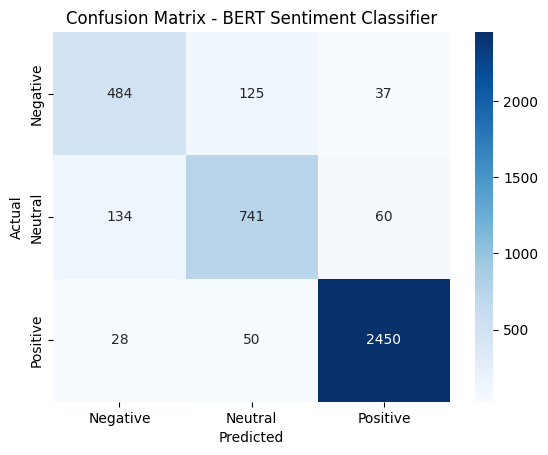

In [15]:
cm = confusion_matrix(test_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT Sentiment Classifier")
plt.show()

In [16]:
report = classification_report(test_labels, preds, target_names=label_map.keys(), output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)


              precision    recall  f1-score      support
Negative       0.749226  0.749226  0.749226   646.000000
Neutral        0.808952  0.792513  0.800648   935.000000
Positive       0.961916  0.969146  0.965517  2528.000000
accuracy       0.894378  0.894378  0.894378     0.894378
macro avg      0.840031  0.836962  0.838464  4109.000000
weighted avg   0.893671  0.894378  0.893997  4109.000000


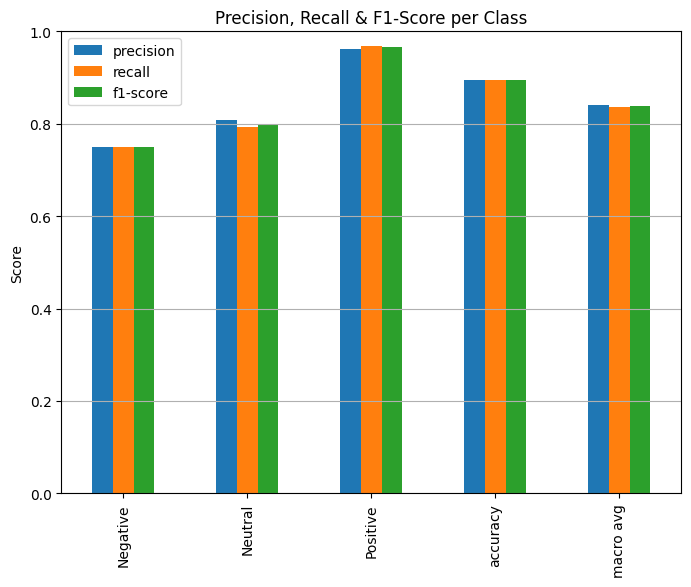

In [17]:
df_report[:-1][['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(8,6))
plt.title("Precision, Recall & F1-Score per Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


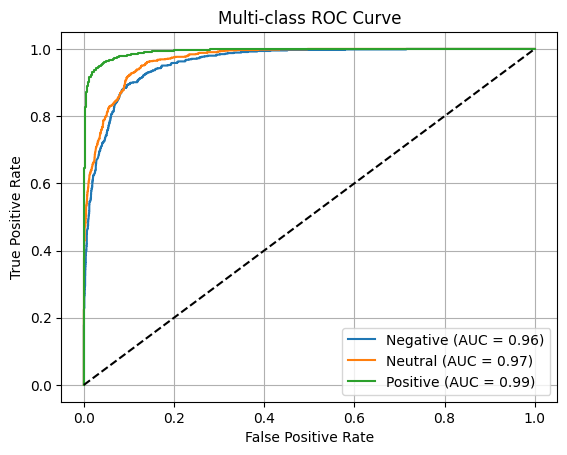

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

y_true = label_binarize(test_labels, classes=[0, 1, 2])
y_scores = preds_output.predictions

fpr = {}
tpr = {}
roc_auc = {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for i, label in enumerate(label_map.keys()):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [19]:
import numpy as np
wrong = np.where(preds != torch.tensor(test_labels))[0]

print("\nExamples of Misclassified Samples:")
for i in wrong[:5]:
    print(f"Text: {test_texts[i]}")
    true_label = list(label_map.keys())[test_labels[i]]
    pred_label = list(label_map.keys())[preds[i]]
    print(f"Actual: {true_label}, Predicted: {pred_label}\n")



Examples of Misclassified Samples:
Text: jpmorgan chase co
Actual: Neutral, Predicted: Negative

Text: world investment advisors llc grew its stake in tesla by 12489 during the 3rd quarter
Actual: Negative, Predicted: Neutral

Text: in light of that when we looked at samsung sdsltd and its roce trend we werent exactly thrilled
Actual: Negative, Predicted: Positive

Text: the same week ibm announced its most recent earnings which showed a 10 increase in its bespoke ai software sales beating analysts expectations
Actual: Negative, Predicted: Positive

Text: tsmc began manufacturing iphone chips in 2014 and apple ditched intel after creating its own macbook chips using arms architecture
Actual: Positive, Predicted: Neutral



In [20]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    return list(label_map.keys())[pred]


print(predict_sentiment("The stock market is crashing badly."))
print(predict_sentiment("Everything is stable."))
print(predict_sentiment("Great performance!"))


Negative
Positive
Positive


In [21]:
print(predict_sentiment("The Google had a great rise in shares."))

Positive


In [22]:
  print(predict_sentiment("Tata has suffered a factory burn down"))

Negative


In [23]:
print(predict_sentiment("Zomato has suffered a loss of 20%"))

Negative


In [24]:
print(predict_sentiment("$400-million unemployment fraud under Biden-era? Elon Musk's DOGE drops another bombshell"))

Negative
